In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load all the data

In [2]:
data_train = pd.read_csv("../data/raw/train.csv")
data_train.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [3]:
data_holidays = pd.read_csv("../data/raw/holidays_events.csv")
data_holidays.head()

,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


In [4]:
data_oil = pd.read_csv("../data/raw/oil.csv")
data_oil.head()

,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20


In [5]:
data_stores = pd.read_csv("../data/raw/stores.csv")
data_stores.head()

,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4


In [6]:
data_transactions = pd.read_csv("../data/raw/transactions.csv")
data_transactions.head()

,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922


## Observe the data
Find all the possible relations in data         
Do holidays have a huge effect?     
Do all the products behave the same? How about stores?    

In [7]:
print("Shape:", data_train.shape)

print("First date:", data_train["date"].min())
print("Last date:", data_train["date"].max())

print("Number of stores:", data_train["store_nbr"].nunique())
print("Number of product families:", data_train["family"].nunique())

Shape: (3000888, 6)
First date: 2013-01-01
Last date: 2017-08-15
Number of stores: 54
Number of product families: 33


### Hypothesis : As we move forward the general sales rises

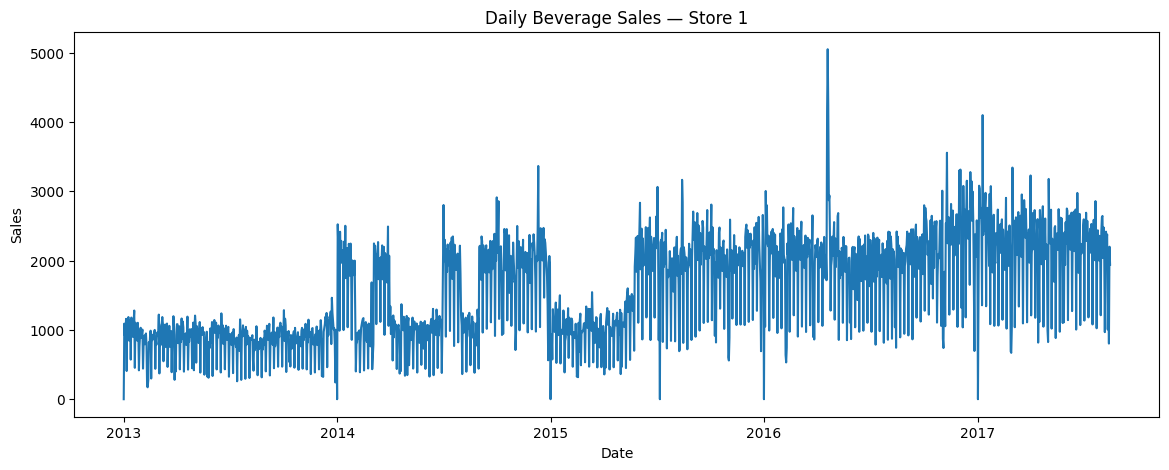

In [8]:
sample = data_train[
    (data_train["store_nbr"] == 1) &
    (data_train["family"] == "BEVERAGES")
].copy()

sample["date"] = pd.to_datetime(sample["date"])

sample = sample.sort_values("date")

plt.figure(figsize=(14, 5))

plt.plot(sample["date"], sample["sales"])

plt.title("Daily Beverage Sales — Store 1")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

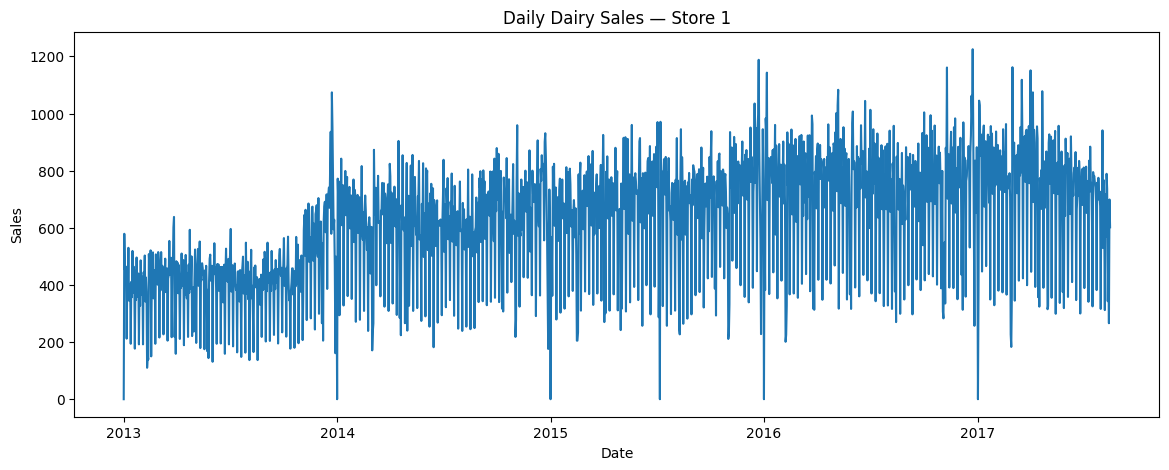

In [9]:
sample2 = data_train[
    (data_train["store_nbr"] == 1) &
    (data_train["family"] == "DAIRY")
].copy()

sample2["date"] = pd.to_datetime(sample2["date"])
sample2 = sample2.sort_values("date")

plt.figure(figsize=(14, 5))
plt.plot(sample2["date"], sample2["sales"])

plt.title("Daily Dairy Sales — Store 1")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

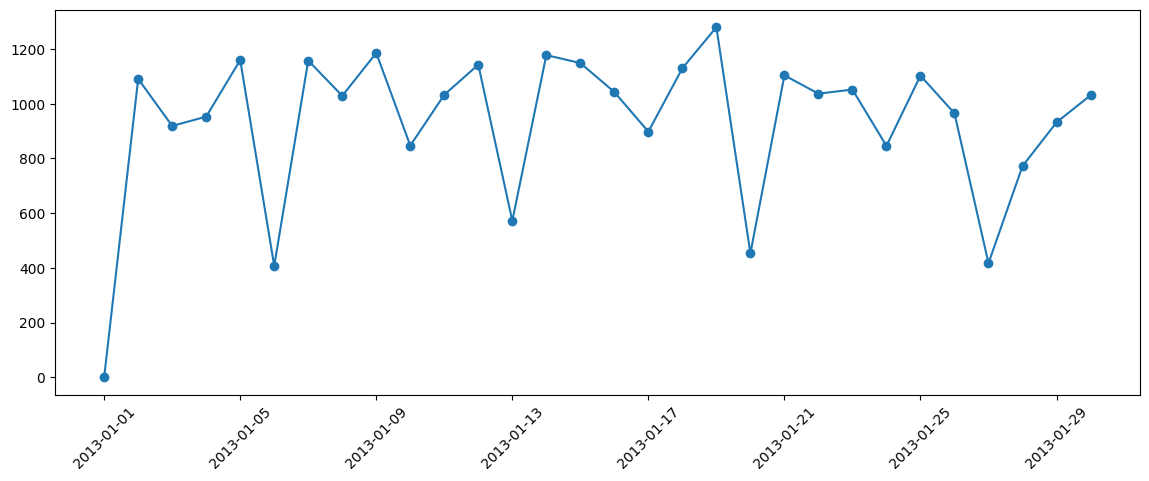

In [10]:
plt.figure(figsize=(14, 5))

plt.plot(
    sample["date"].head(30),
    sample["sales"].head(30),
    marker="o"
)

plt.xticks(rotation=45)
plt.show()

### Hypothesis: There's a weekly pattern. We have a great loss in sales on Sundays

In [11]:
sample['day'] = sample['date'].dt.dayofweek
grouped_sample = sample.groupby('day', as_index=False).mean(numeric_only=True)
grouped_sample[['day', 'sales']]

,day,sales
0,0,1700.294606
1,1,1651.483471
2,2,1847.425000
3,3,1576.458333
4,4,1732.033333
5,5,1820.576763
6,6,784.000000


In [12]:
print(sample.shape)
print(sample["date"].min(), sample["date"].max())
print(sample['date'].dt.dayofweek.value_counts())

(1684, 7)
2013-01-01 00:00:00 2017-08-15 00:00:00
date
1    242
0    241
5    241
3    240
2    240
4    240
6    240
Name: count, dtype: int64


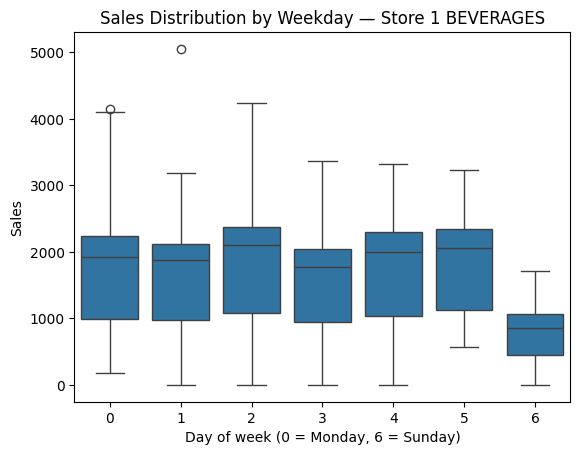

In [13]:
sns.boxplot(data=sample, x="day", y="sales")

plt.xlabel("Day of week (0 = Monday, 6 = Sunday)")
plt.ylabel("Sales")
plt.title("Sales Distribution by Weekday — Store 1 BEVERAGES")

plt.show()

### Hypothesis : Sundays have a low sale

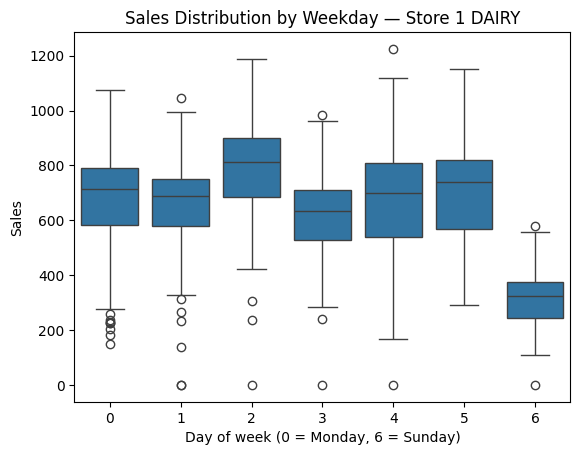

In [14]:
sample2 = data_train[
    (data_train["store_nbr"] == 1) &
    (data_train["family"] == "DAIRY")
].copy()

sample2["date"] = pd.to_datetime(sample2["date"])
sample2["day"] = sample2["date"].dt.dayofweek

sns.boxplot(data=sample2, x="day", y="sales")

plt.xlabel("Day of week (0 = Monday, 6 = Sunday)")
plt.ylabel("Sales")
plt.title("Sales Distribution by Weekday — Store 1 DAIRY")

plt.show()

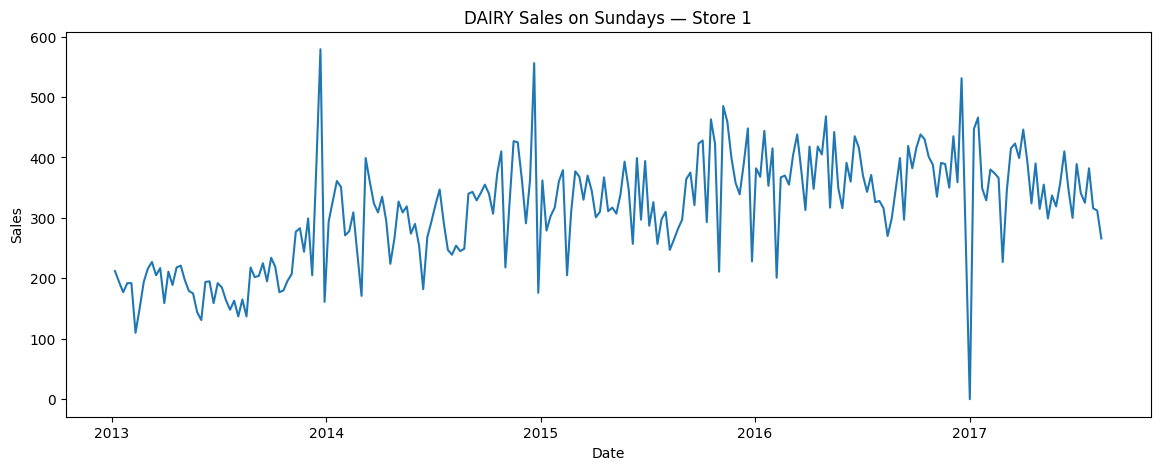

In [15]:
sunday = sample2[sample2["day"] == 6]

plt.figure(figsize=(14, 5))
plt.plot(sunday["date"], sunday["sales"])
plt.title("DAIRY Sales on Sundays — Store 1")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

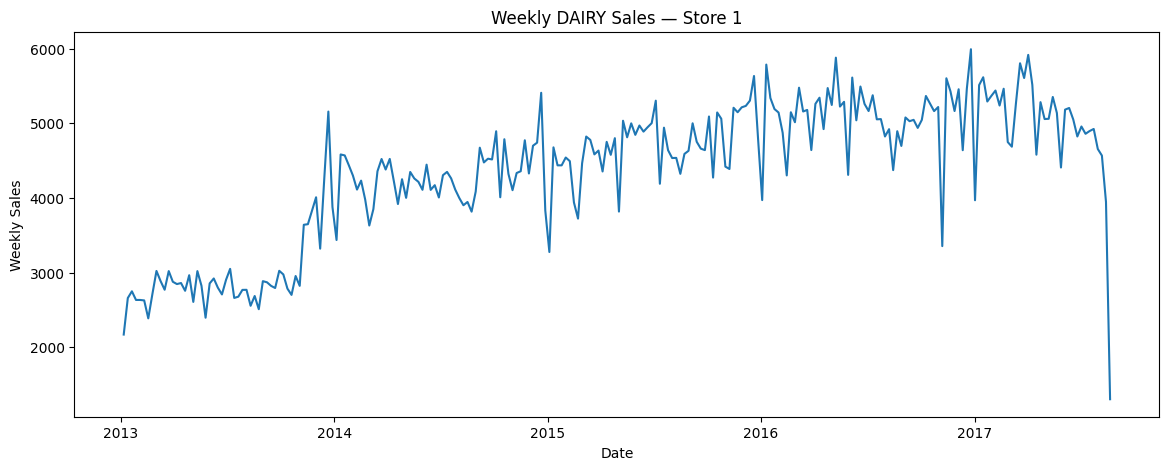

In [16]:
sample2 = sample2.sort_values("date")

weekly = (
    sample2
    .set_index("date")["sales"]
    .resample("W")
    .sum()
)

plt.figure(figsize=(14, 5))
plt.plot(weekly)
plt.title("Weekly DAIRY Sales — Store 1")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.show()

In [17]:
weekly.sort_values().head(10)

date
2017-08-20    1301.0
2013-01-06    2168.0
2013-02-17    2385.0
2013-05-26    2394.0
2013-08-25    2508.0
2013-08-11    2554.0
2013-05-05    2606.0
2013-02-10    2626.0
2013-01-27    2632.0
2013-02-03    2632.0
Name: sales, dtype: float64

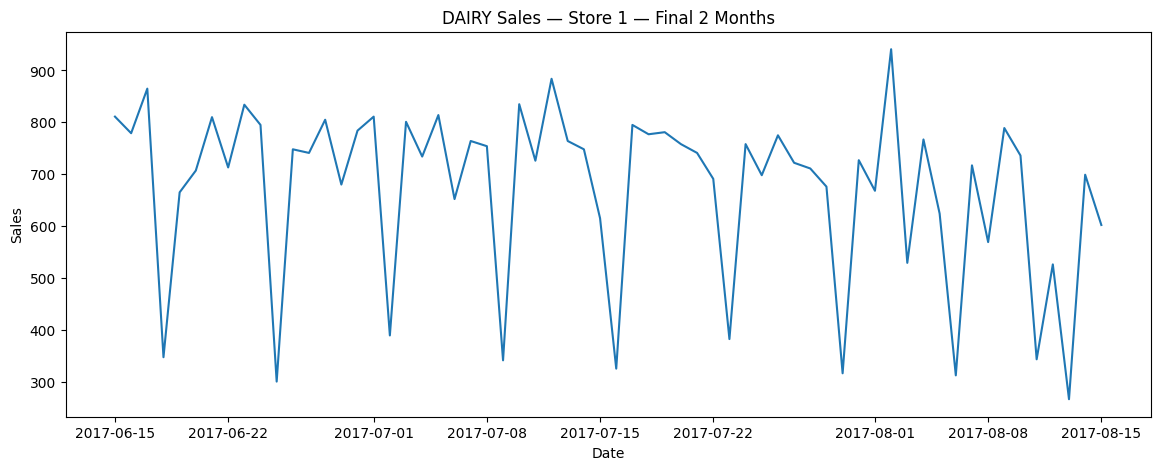

In [18]:
recent = sample2[sample2["date"] >= "2017-06-15"]

plt.figure(figsize=(14, 5))
plt.plot(recent["date"], recent["sales"])
plt.title("DAIRY Sales — Store 1 — Final 2 Months")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

### Work on hypothesis

We'll work towards confirming the two patterns found here:
1. we have a general rise as time goes by
2. we have a low sales day on Sundays

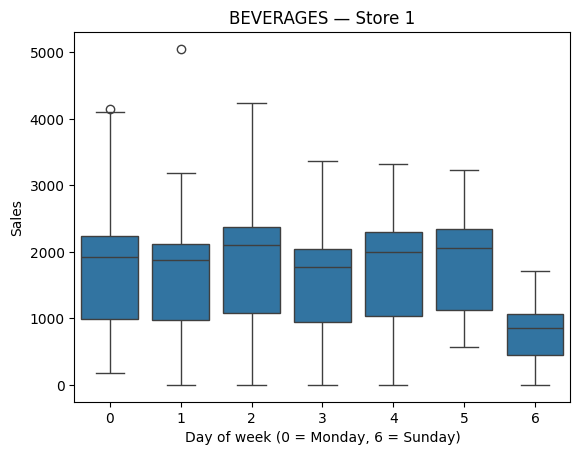

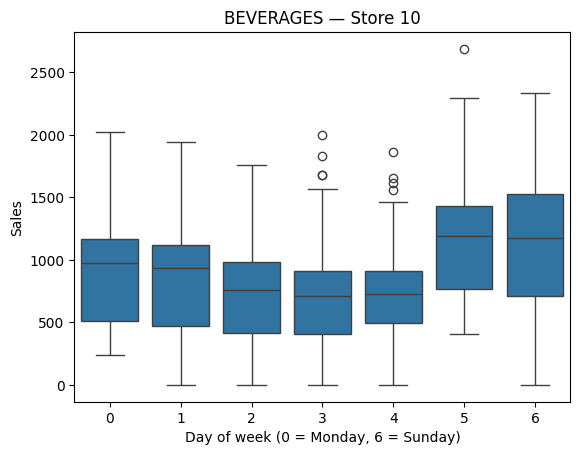

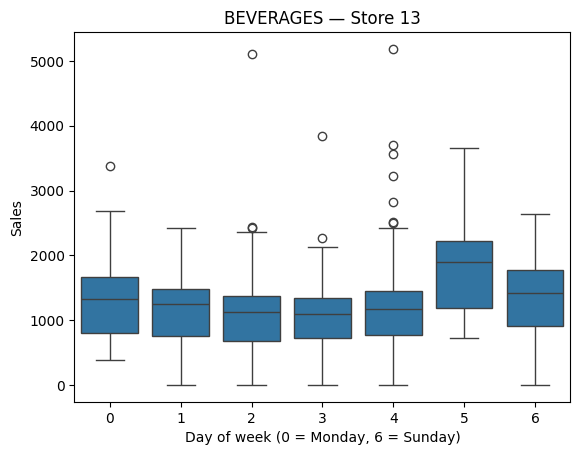

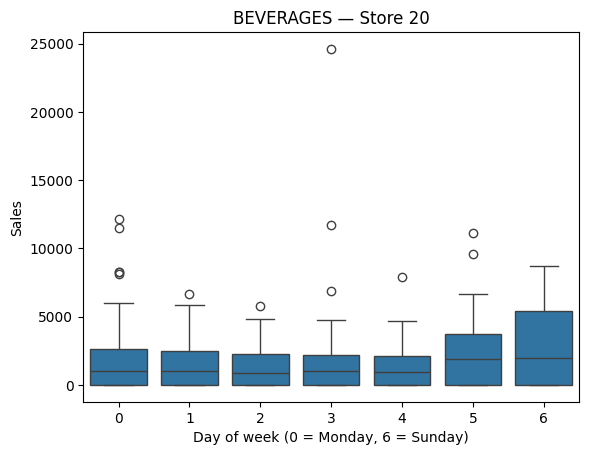

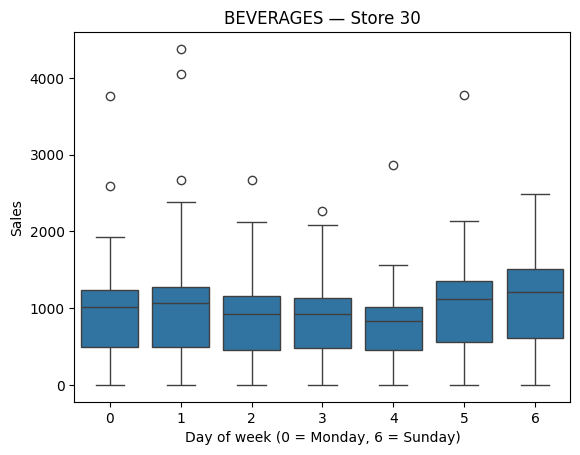

In [19]:
stores_to_check = [1, 10, 13, 20, 30]

for store in stores_to_check:

    temp = data_train[
        (data_train["store_nbr"] == store) &
        (data_train["family"] == "BEVERAGES")
    ].copy()

    temp["date"] = pd.to_datetime(temp["date"])
    temp["day"] = temp["date"].dt.dayofweek

    sns.boxplot(data=temp, x="day", y="sales")

    plt.title(f"BEVERAGES — Store {store}")
    plt.xlabel("Day of week (0 = Monday, 6 = Sunday)")
    plt.ylabel("Sales")
    plt.show()

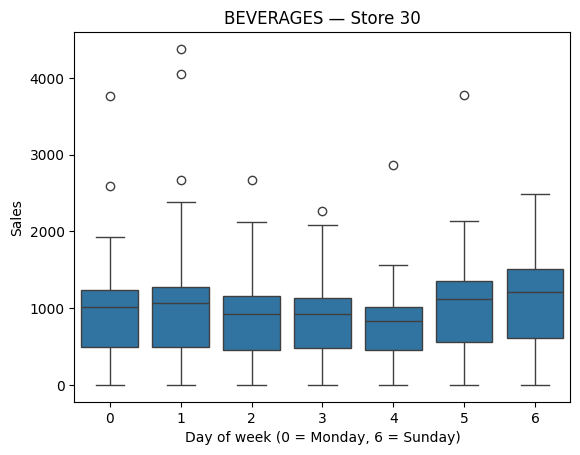

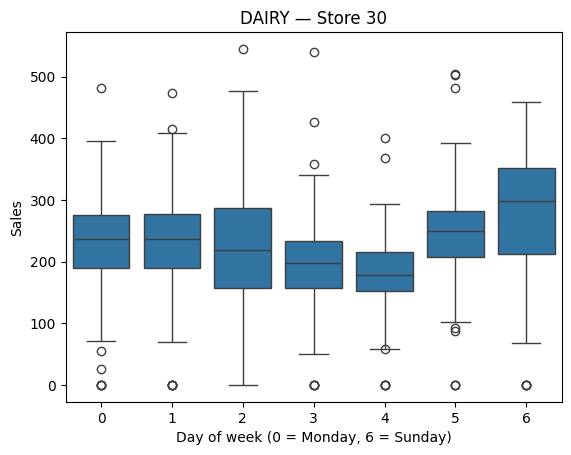

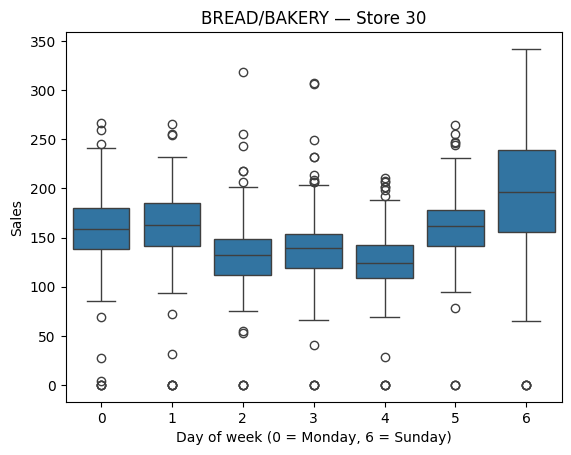

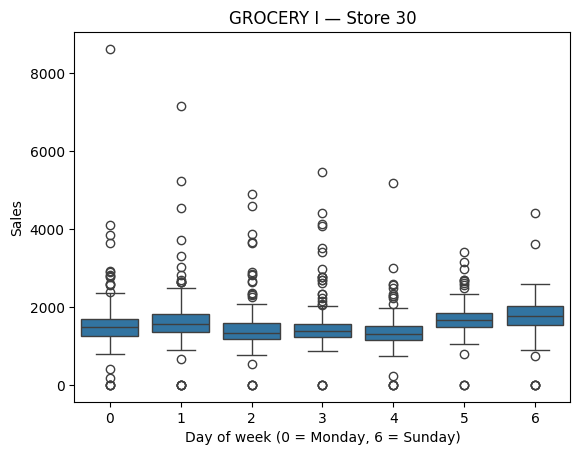

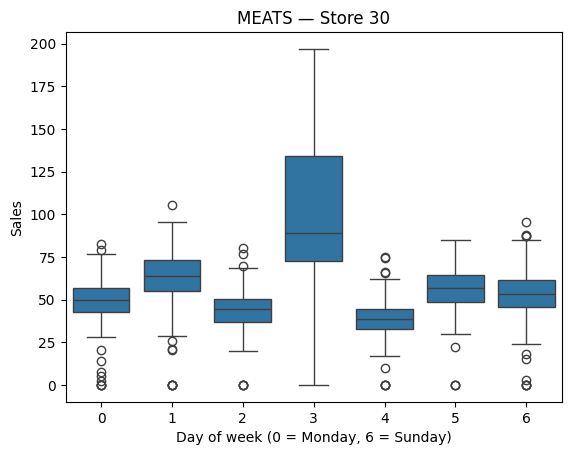

In [20]:
families = ["BEVERAGES", "DAIRY", "BREAD/BAKERY", "GROCERY I", "MEATS"]

for family in families:

    temp = data_train[
        (data_train["store_nbr"] == 30) &
        (data_train["family"] == family)
    ].copy()

    temp["date"] = pd.to_datetime(temp["date"])
    temp["day"] = temp["date"].dt.dayofweek

    sns.boxplot(data=temp, x="day", y="sales")

    plt.title(f"{family} — Store 30")
    plt.xlabel("Day of week (0 = Monday, 6 = Sunday)")
    plt.ylabel("Sales")
    plt.show()

Do we have a general rise in sales?

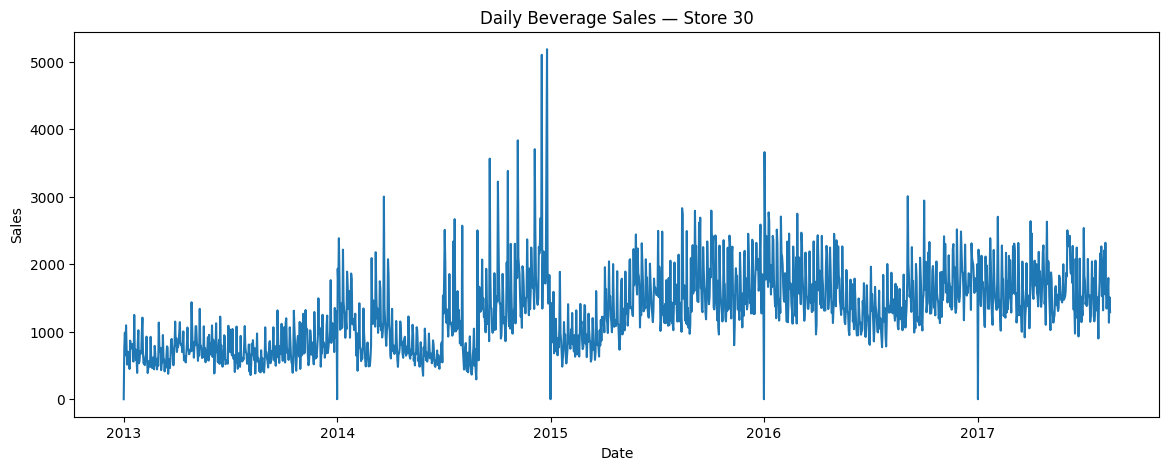

In [21]:
sample = data_train[
    (data_train["store_nbr"] == 13) &
    (data_train["family"] == "BEVERAGES")
].copy()

sample["date"] = pd.to_datetime(sample["date"])

sample = sample.sort_values("date")

plt.figure(figsize=(14, 5))

plt.plot(sample["date"], sample["sales"])

plt.title("Daily Beverage Sales — Store 30")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

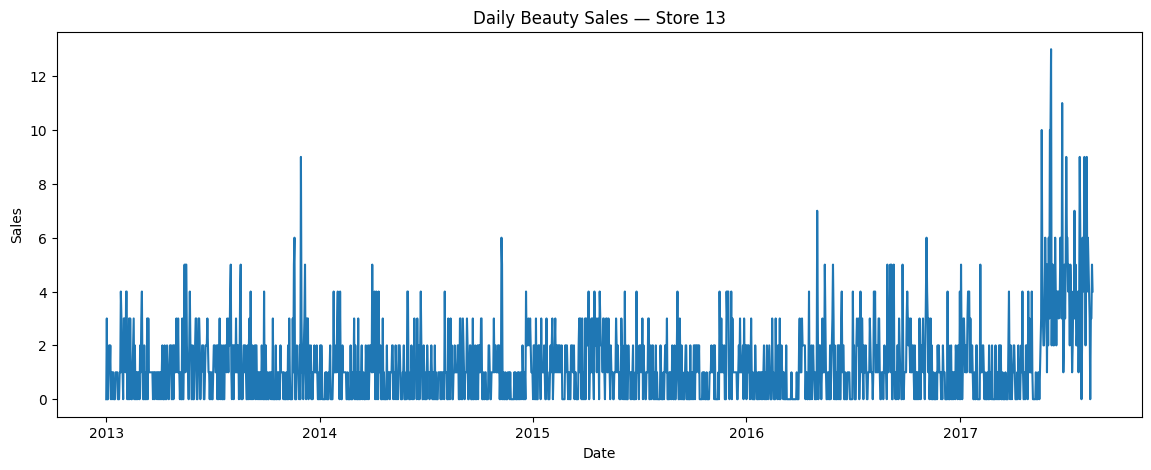

In [76]:
sample = data_train[
    (data_train["store_nbr"] == 13) &
    (data_train["family"] == "BEAUTY")
].copy()

sample["date"] = pd.to_datetime(sample["date"])

sample = sample.sort_values("date")

plt.figure(figsize=(14, 5))

plt.plot(sample["date"], sample["sales"])

plt.title("Daily Beauty Sales — Store 13")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

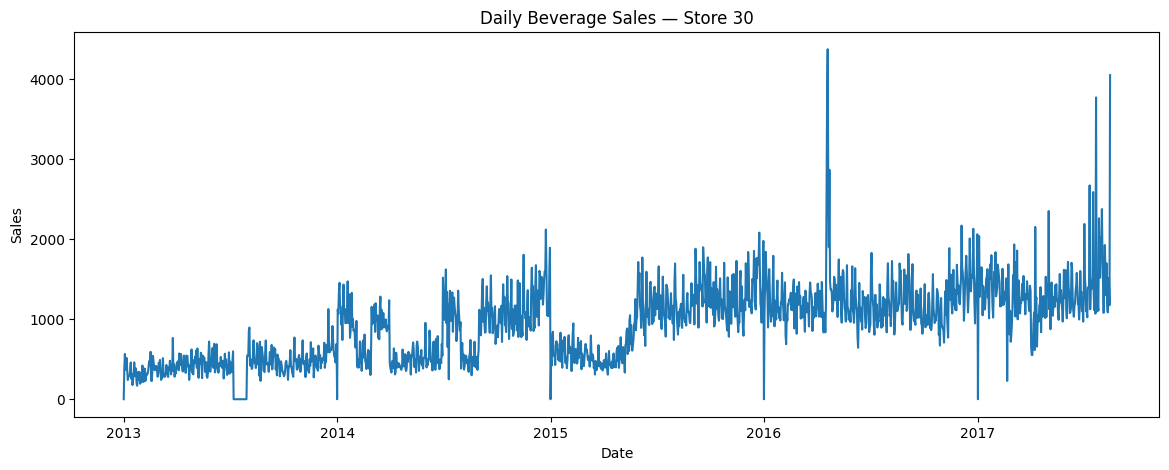

In [23]:
sample = data_train[
    (data_train["store_nbr"] == 30) &
    (data_train["family"] == "BEVERAGES")
].copy()

sample["date"] = pd.to_datetime(sample["date"])

sample = sample.sort_values("date")

plt.figure(figsize=(14, 5))

plt.plot(sample["date"], sample["sales"])

plt.title("Daily Beverage Sales — Store 30")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

Do we have a weekly trend in different families in different stores? 

In [24]:
temp = data_train[data_train["store_nbr"] == 30].copy()

temp["date"] = pd.to_datetime(temp["date"])
temp["day"] = temp["date"].dt.dayofweek

weekday_family = (
    temp.groupby(["family", "day"])["sales"]
    .mean()
    .unstack()
)

weekday_family

day,0,1,2,3,4,5,6
family,,,,,,,
AUTOMOTIVE,2.929461,3.090909,2.604167,3.050000,2.850000,3.668050,3.383333
BABY CARE,0.099585,0.074380,0.058333,0.058333,0.045833,0.078838,0.050000
BEAUTY,0.614108,0.582645,0.508333,0.483333,0.487500,0.726141,0.779167
BEVERAGES,937.373444,983.004132,856.662500,855.229167,771.975000,1010.336100,1104.037500
BOOKS,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
BREAD/BAKERY,157.165975,159.429752,131.366667,137.183333,124.737500,159.219917,195.283333
CELEBRATION,1.970954,2.000000,2.500000,2.525000,2.666667,3.041494,2.300000
CLEANING,491.178423,494.648760,421.254167,442.029167,458.654167,545.145228,508.845833
DAIRY,223.456432,224.892562,220.533333,192.875000,178.791667,239.858921,277.795833


## New Approach
We have to have a more general view

In [26]:
data_train["date"] = pd.to_datetime(data_train["date"])

monthly = (
    data_train.groupby([
        pd.Grouper(key="date", freq="MS"),
        "family"
    ])["sales"]
    .sum()
    .reset_index()
)

monthly.head()

,date,family,sales
0,2013-01-01,AUTOMOTIVE,6557.0
1,2013-01-01,BABY CARE,0.0
2,2013-01-01,BEAUTY,4019.0
3,2013-01-01,BEVERAGES,1670653.0
4,2013-01-01,BOOKS,0.0


In [27]:
monthly.tail()

,date,family,sales
1843,2017-08-01,POULTRY,3.038527e+05
1844,2017-08-01,PREPARED FOODS,7.129793e+04
1845,2017-08-01,PRODUCE,1.855595e+06
1846,2017-08-01,SCHOOL AND OFFICE SUPPLIES,5.016900e+04
1847,2017-08-01,SEAFOOD,1.615455e+04


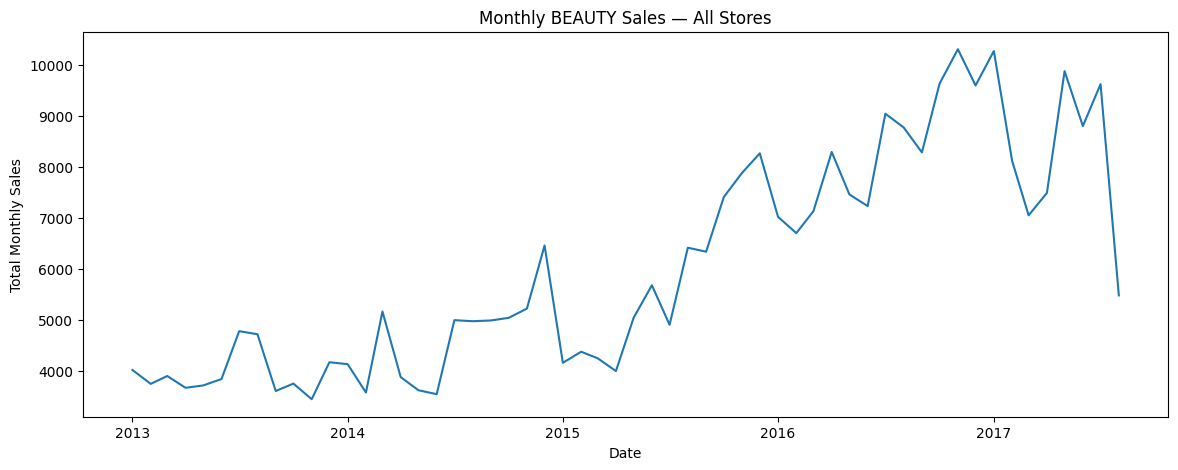

In [28]:
beauty = monthly[monthly["family"] == "BEAUTY"]

plt.figure(figsize=(14, 5))
plt.plot(beauty["date"], beauty["sales"])

plt.title("Monthly BEAUTY Sales — All Stores")
plt.xlabel("Date")
plt.ylabel("Total Monthly Sales")
plt.show()

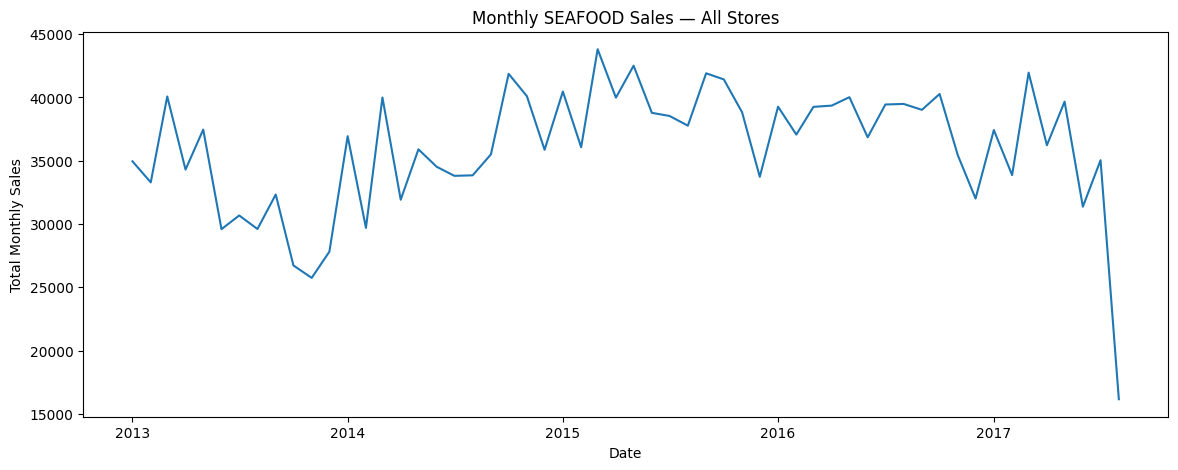

In [29]:
seafood = monthly[monthly["family"] == "SEAFOOD"]

plt.figure(figsize=(14, 5))
plt.plot(seafood["date"], seafood["sales"])

plt.title("Monthly SEAFOOD Sales — All Stores")
plt.xlabel("Date")
plt.ylabel("Total Monthly Sales")
plt.show()

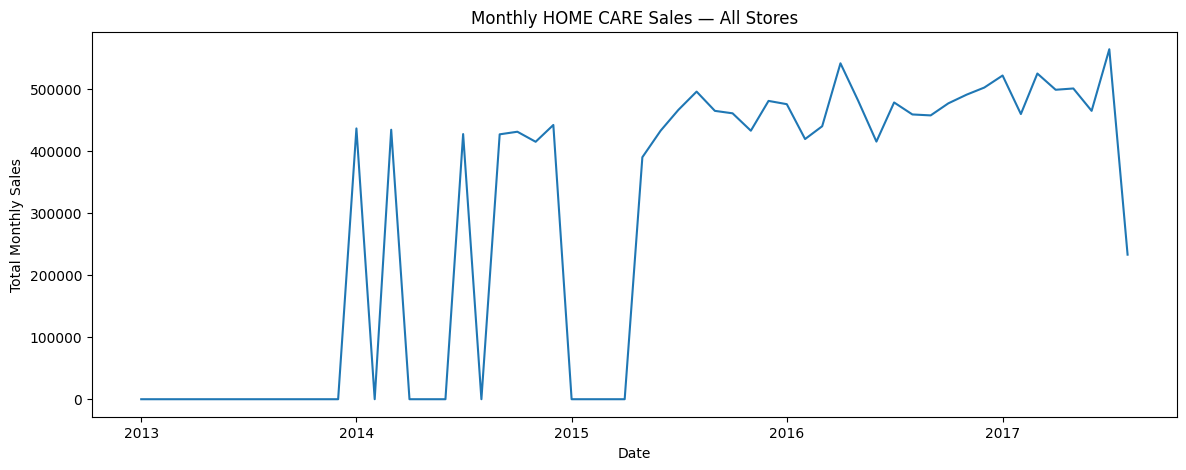

In [30]:
homecare = monthly[monthly["family"] == "HOME CARE"]

plt.figure(figsize=(14, 5))
plt.plot(homecare["date"], homecare["sales"])

plt.title("Monthly HOME CARE Sales — All Stores")
plt.xlabel("Date")
plt.ylabel("Total Monthly Sales")
plt.show()

In [31]:
trend_summary = (
    monthly.groupby("family")
    .apply(
        lambda x: pd.Series({
            "first_month_sales": x.iloc[0]["sales"],
            "last_month_sales": x.iloc[-1]["sales"],
            "min_month_sales": x["sales"].min(),
            "max_month_sales": x["sales"].max(),
        }),
        include_groups=False
    )
)

trend_summary.sort_values(
    "last_month_sales",
    ascending=False
)

,first_month_sales,last_month_sales,min_month_sales,max_month_sales
family,,,,
GROCERY I,4.032240e+06,3.710197e+06,3.710197e+06,9.454953e+06
BEVERAGES,1.670653e+06,2.809903e+06,1.508254e+06,6.204055e+06
PRODUCE,0.000000e+00,1.855595e+06,0.000000e+00,4.119033e+06
CLEANING,1.448851e+06,9.758580e+05,9.758580e+05,2.299087e+06
DAIRY,5.237370e+05,6.745410e+05,4.998730e+05,1.628448e+06
BREAD/BAKERY,5.497789e+05,4.364138e+05,4.364138e+05,9.599072e+05
POULTRY,3.042568e+05,3.038527e+05,2.843664e+05,7.012114e+05
MEATS,5.331548e+05,3.029687e+05,3.029687e+05,6.721154e+05
PERSONAL CARE,3.177160e+05,2.589670e+05,2.589670e+05,6.212470e+05


Since some start at zero we can't count them inside of a trend
and it's better to not consider the last month since it's not complete

In [38]:
complete_months = monthly[monthly["date"] < "2017-08-01"]

records = []

for family, x in complete_months.groupby("family"):
    x = x.sort_values("date")

    records.append({
        "family": family,
        "jan_2013": x.iloc[0]["sales"],
        "jul_2017": x.iloc[-1]["sales"],
    })

comparison = pd.DataFrame(records).set_index("family")

comparison = comparison[
    (comparison["jan_2013"] > 0)
]

comparison["change"] = (
    comparison["jul_2017"] - comparison["jan_2013"]
)

comparison.sort_values("change")

,jan_2013,jul_2017,change
family,,,
LINGERIE,1.826600e+04,1.088400e+04,-7.382000e+03
SEAFOOD,3.495383e+04,3.504069e+04,8.685301e+01
HOME APPLIANCES,2.100000e+02,6.710000e+02,4.610000e+02
HARDWARE,1.612000e+03,2.552000e+03,9.400000e+02
BEAUTY,4.019000e+03,9.623000e+03,5.604000e+03
AUTOMOTIVE,6.557000e+03,1.219700e+04,5.640000e+03
PREPARED FOODS,1.364880e+05,1.514219e+05,1.493388e+04
LAWN AND GARDEN,3.808000e+03,2.750000e+04,2.369200e+04
GROCERY II,2.703900e+04,5.794200e+04,3.090300e+04


They mostly experience overall growth but the growth differs drastically.

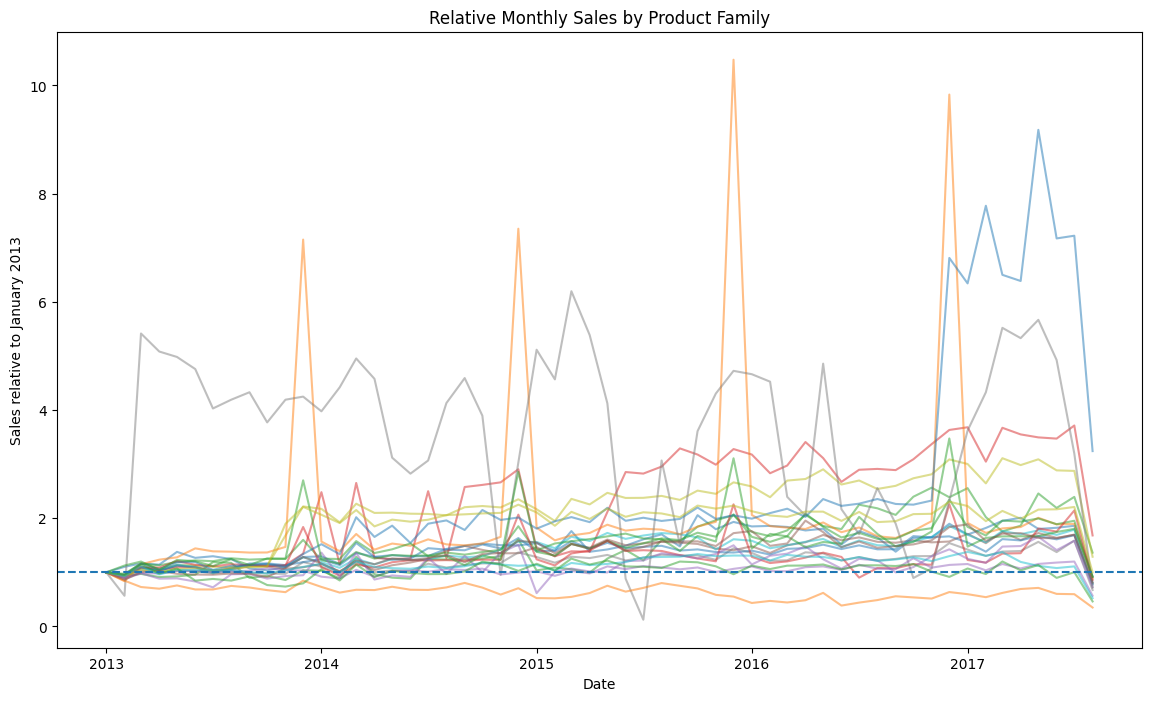

In [39]:
normalized = monthly.copy()

normalized["relative_sales"] = (
    normalized.groupby("family")["sales"]
    .transform(lambda x: x / x.iloc[0])
)

plt.figure(figsize=(14, 8))

for family, group in normalized.groupby("family"):
    plt.plot(
        group["date"],
        group["relative_sales"],
        alpha=0.5
    )

plt.axhline(1, linestyle="--")
plt.title("Relative Monthly Sales by Product Family")
plt.xlabel("Date")
plt.ylabel("Sales relative to January 2013")
plt.show()

In [43]:
monthly_complete = monthly[monthly["date"] < "2017-08-01"]

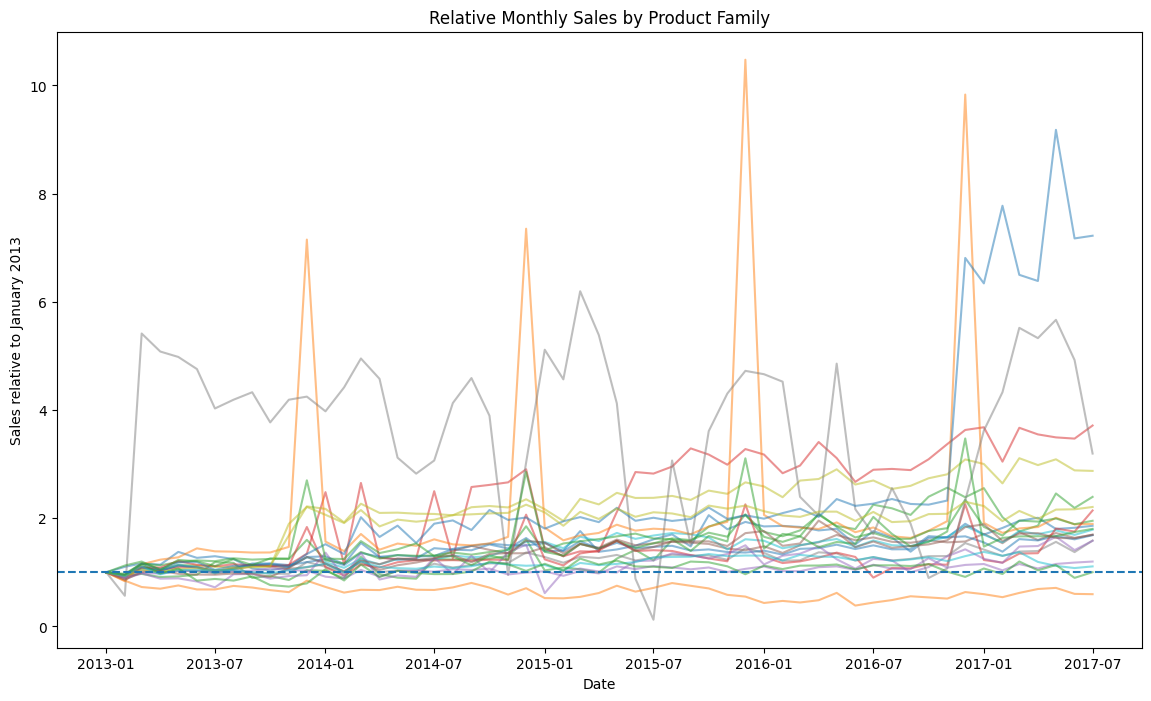

In [44]:
normalized = monthly_complete.copy()

normalized["relative_sales"] = (
    normalized.groupby("family")["sales"]
    .transform(lambda x: x / x.iloc[0])
)

plt.figure(figsize=(14, 8))

for family, group in normalized.groupby("family"):
    plt.plot(
        group["date"],
        group["relative_sales"],
        alpha=0.5
    )

plt.axhline(1, linestyle="--")
plt.title("Relative Monthly Sales by Product Family")
plt.xlabel("Date")
plt.ylabel("Sales relative to January 2013")
plt.show()

## Viewing other datasets to better understand the trends

### Stores Data

In [46]:
data_stores.head()

,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4


In [47]:
data_stores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   store_nbr  54 non-null     int64 
 1   city       54 non-null     object
 2   state      54 non-null     object
 3   type       54 non-null     object
 4   cluster    54 non-null     int64 
dtypes: int64(2), object(3)
memory usage: 2.2+ KB


In [48]:
data_stores["type"].value_counts()

type
D    18
C    15
A     9
B     8
E     4
Name: count, dtype: int64

### Do different stores have different overall sales?

In [50]:
data_merged_stores = data_train.merge(
    data_stores,
    on="store_nbr",
    how="left"
)
data_merged_stores.head()

,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13
2,2,2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13
3,3,2013-01-01,1,BEVERAGES,0.0,0,Quito,Pichincha,D,13
4,4,2013-01-01,1,BOOKS,0.0,0,Quito,Pichincha,D,13


In [51]:
type_sales = (
    data_merged_stores
    .groupby("type")["sales"]
    .mean()
    .sort_values(ascending=False)
)

type_sales

type
A    705.878743
D    350.979407
B    326.739714
E    269.121301
C    197.263301
Name: sales, dtype: float64

Does this happen because of product mix or is this a pattern?

In [53]:
beverages = data_merged_stores[data_merged_stores["family"] == "BEVERAGES"]

beverages.groupby("type")["sales"].mean().sort_values(ascending=False)

type
A    4737.978292
D    2295.226577
B    2145.153058
E    2120.455463
C    1282.260055
Name: sales, dtype: float64

We'll try to find out if this a general pattern    
Does store A sell double store D, and store C sells very low

In [54]:
family_type_sales = (
    data_merged_stores
    .groupby(["family", "type"])["sales"]
    .mean()
    .unstack()
)

family_type_sales

type,A,B,C,D,E
family,,,,,
AUTOMOTIVE,12.128728,6.658700,4.451702,4.455034,5.018112
BABY CARE,0.000000,0.259130,0.172763,0.053972,0.083135
BEAUTY,8.578121,3.299807,1.053880,4.177191,1.512470
BEVERAGES,4737.978292,2145.153058,1282.260055,2295.226577,2120.455463
BOOKS,0.194510,0.000000,0.000000,0.115136,0.000000
BREAD/BAKERY,848.068565,522.525914,179.900435,493.338522,407.183343
CELEBRATION,16.035366,6.338554,3.832937,9.826669,5.651128
CLEANING,1853.772367,1124.702049,828.549010,914.480635,835.012470
DAIRY,1522.129982,507.997996,284.445487,801.134468,461.026871


The average of 4 years seems to follow the trend however:     
- the scales are very different   
- there are exceptinos in which A isn't the highest
- some items aren't sold in some stores (books)     
Does this "trend" stay consistent during the time?

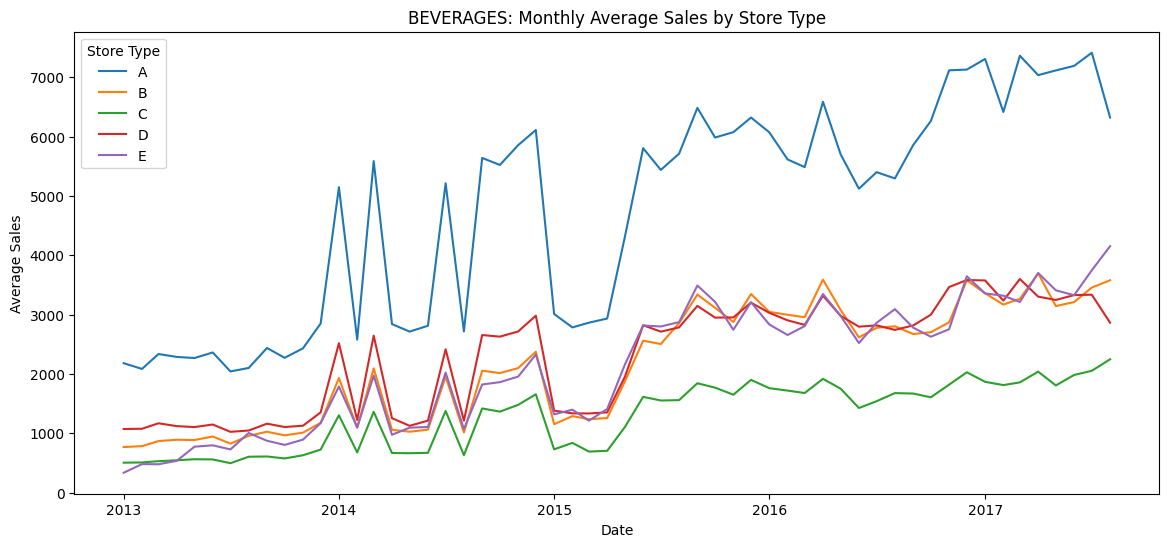

In [55]:
beverages = data_merged_stores[data_merged_stores["family"] == "BEVERAGES"].copy()

beverages_monthly = (
    beverages
    .groupby([
        pd.Grouper(key="date", freq="MS"),
        "type"
    ])["sales"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(14, 6))

for store_type, group in beverages_monthly.groupby("type"):
    plt.plot(
        group["date"],
        group["sales"],
        label=store_type
    )

plt.title("BEVERAGES: Monthly Average Sales by Store Type")
plt.xlabel("Date")
plt.ylabel("Average Sales")
plt.legend(title="Store Type")
plt.show()

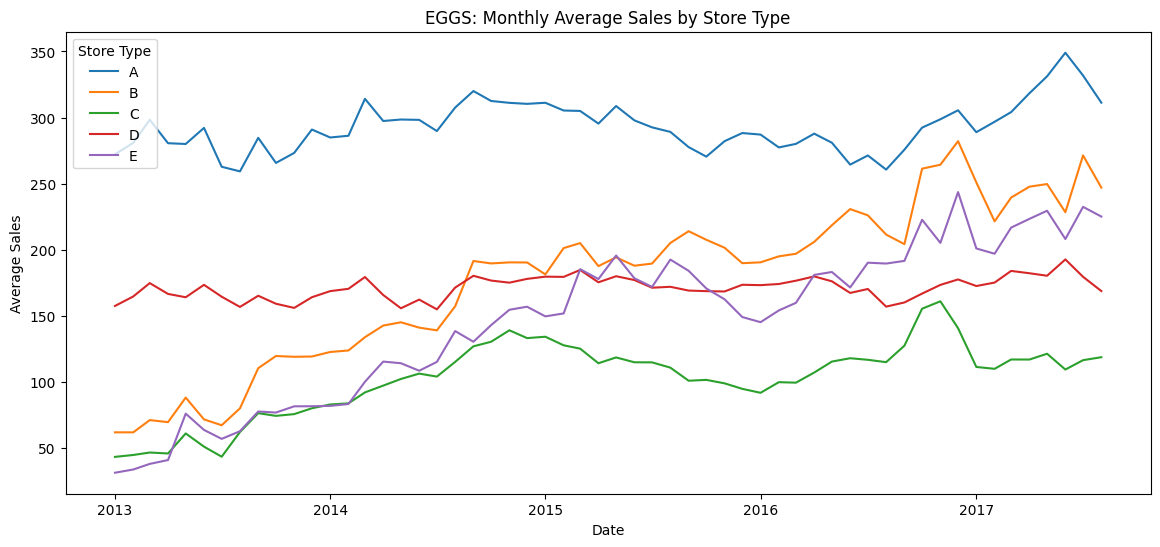

In [75]:
eggs = data_merged_stores[data_merged_stores["family"] == "EGGS"].copy()

eggs_monthly = (
    eggs
    .groupby([
        pd.Grouper(key="date", freq="MS"),
        "type"
    ])["sales"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(14, 6))

for store_type, group in eggs_monthly.groupby("type"):
    plt.plot(
        group["date"],
        group["sales"],
        label=store_type
    )

plt.title("EGGS: Monthly Average Sales by Store Type")
plt.xlabel("Date")
plt.ylabel("Average Sales")
plt.legend(title="Store Type")
plt.show()

The most intersting thing here is how their spikes and falls are coordinated. This might because of an event or holiday which we should investigate

### Holidays and Events Data

In [59]:
data_holidays.head()

,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


In [61]:
data_holidays.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   date         350 non-null    object
 1   type         350 non-null    object
 2   locale       350 non-null    object
 3   locale_name  350 non-null    object
 4   description  350 non-null    object
 5   transferred  350 non-null    bool  
dtypes: bool(1), object(5)
memory usage: 14.1+ KB


In [63]:
data_holidays["type"].value_counts()

type
Holiday       221
Event          56
Additional     51
Transfer       12
Bridge          5
Work Day        5
Name: count, dtype: int64

In [64]:
data_holidays["locale"].value_counts()

locale
National    174
Local       152
Regional     24
Name: count, dtype: int64

In [66]:
data_holidays["date"] = pd.to_datetime(data_holidays["date"])

national = data_holidays[
    data_holidays["locale"] == "National"
]

national[
    (national["date"] >= "2013-01-01") &
    (national["date"] <= "2017-08-15")
][["date", "type", "description", "transferred"]].sort_values("date")

,date,type,description,transferred
41,2013-01-01,Holiday,Primer dia del ano,False
42,2013-01-05,Work Day,Recupero puente Navidad,False
43,2013-01-12,Work Day,Recupero puente primer dia del ano,False
44,2013-02-11,Holiday,Carnaval,False
45,2013-02-12,Holiday,Carnaval,False
...,...,...,...,...
311,2017-05-14,Event,Dia de la Madre,False
312,2017-05-24,Holiday,Batalla de Pichincha,True
313,2017-05-26,Transfer,Traslado Batalla de Pichincha,False
324,2017-08-10,Holiday,Primer Grito de Independencia,True


In [69]:
national_dates = (
    national[
        (national["date"] >= "2013-01-01") &
        (national["date"] <= "2017-08-15")
    ]
    .groupby("date")
    .size()
)

len(national_dates)

147

find the connection

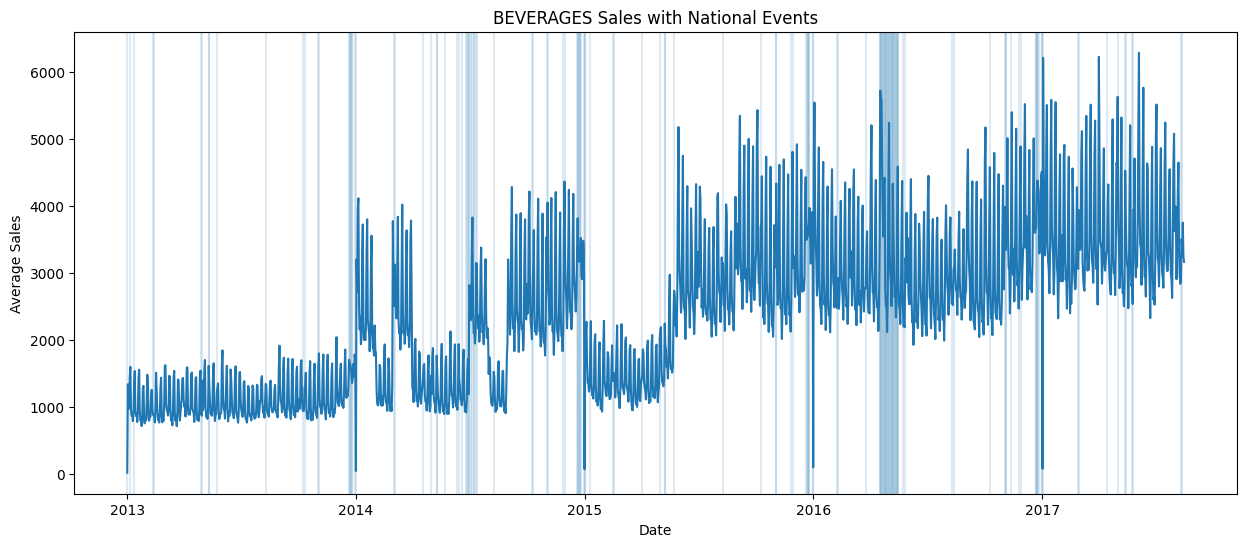

In [70]:
beverages = data_merged_stores[data_merged_stores["family"] == "BEVERAGES"]

daily_beverages = (
    beverages.groupby("date")["sales"]
    .mean()
)

plt.figure(figsize=(15, 6))

plt.plot(daily_beverages.index, daily_beverages.values)

for date in national_dates.index:
    plt.axvline(date, alpha=0.15)

plt.title("BEVERAGES Sales with National Events")
plt.xlabel("Date")
plt.ylabel("Average Sales")
plt.show()

national holidays collide with spikes/drops but doesn't seem like a conclusion

In [71]:
national.groupby("type").size()

type
Additional    40
Bridge         5
Event         56
Holiday       60
Transfer       8
Work Day       5
dtype: int64

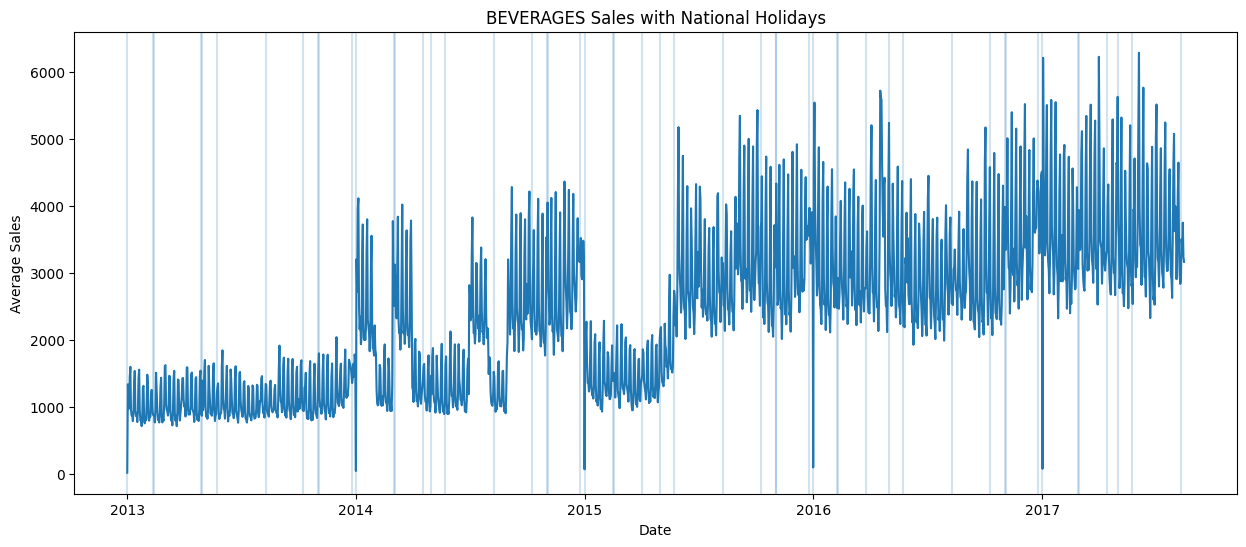

In [72]:
national_holidays = national[
    (national["type"] == "Holiday") &
    (national["date"] >= "2013-01-01") &
    (national["date"] <= "2017-08-15")
]

nati

plt.figure(figsize=(15, 6))

plt.plot(daily_beverages.index, daily_beverages.values)

for date in national_holidays["date"]:
    plt.axvline(date, alpha=0.2)

plt.title("BEVERAGES Sales with National Holidays")
plt.xlabel("Date")
plt.ylabel("Average Sales")
plt.show()

This is more clear.
On holidays we tend to have a drop.

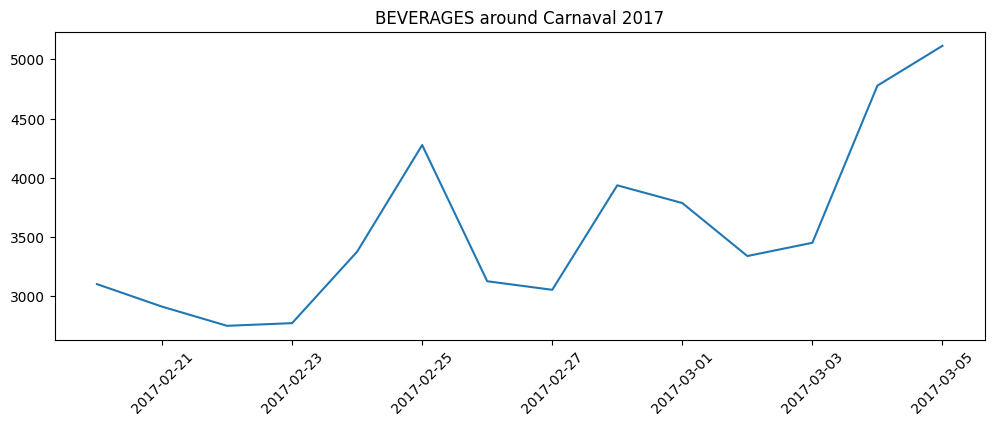

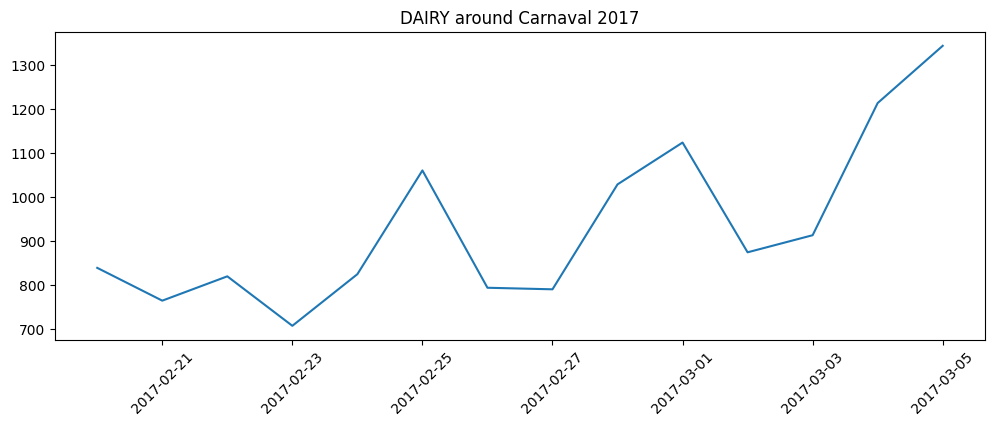

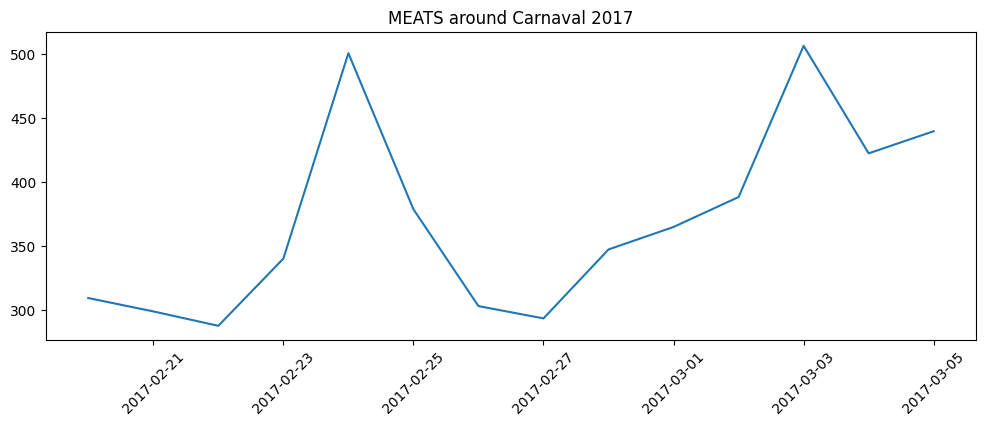

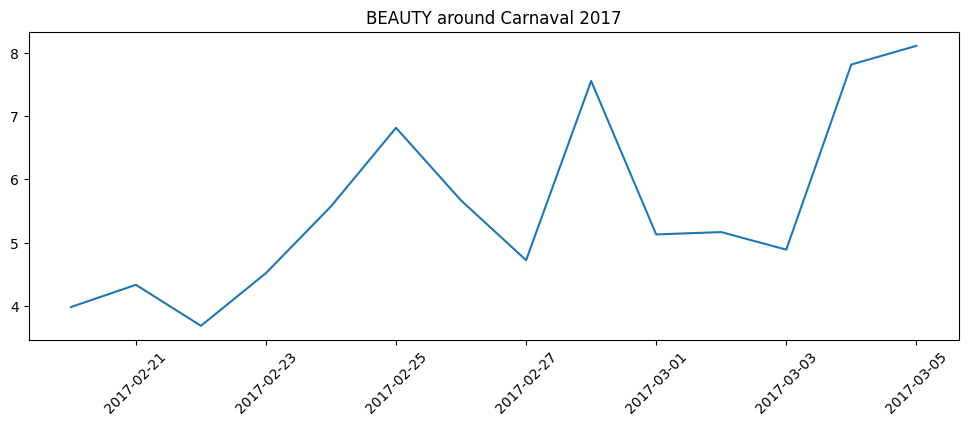

In [74]:
families = ["BEVERAGES", "DAIRY", "MEATS", "BEAUTY"]

for family in families:
    temp = data_merged_stores[data_merged_stores["family"] == family]
    
    daily = temp.groupby("date")["sales"].mean()
    
    window = daily.loc["2017-02-20":"2017-03-05"]
    
    plt.figure(figsize=(12, 4))
    plt.plot(window.index, window.values)
    plt.title(f"{family} around Carnaval 2017")
    plt.xticks(rotation=45)
    plt.show()